<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Check_UnbalanceTechnique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Imbalanced-learn utilities
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Precision, Recall, AUC

In [3]:
# Provide path
df = pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')

In [4]:
# Copy data
data = df.copy()

In [6]:
# Initiate X and Y
X = data.drop(columns=['Churn'])
y = data['Churn']

# Split dataset into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scale features to [0,1] using MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check shapes and class distribution
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())

Train shape: (5634, 17) (5634,)
Test shape: (1409, 17) (1409,)
Train class counts:
 Churn
0    4139
1    1495
Name: count, dtype: int64
Test class counts:
 Churn
0    1035
1     374
Name: count, dtype: int64


# **1. With Class Weights**

Class weights: {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7022 - auc: 0.7607 - f1_score: 0.5517 - loss: 0.6157 - precision: 0.4715 - recall: 0.7017 - val_accuracy: 0.7187 - val_auc: 0.7951 - val_f1_score: 0.5672 - val_loss: 0.5385 - val_precision: 0.4758 - val_recall: 0.7322
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7559 - auc: 0.8321 - f1_score: 0.6299 - loss: 0.5119 - precision: 0.5260 - recall: 0.7951 - val_accuracy: 0.7223 - val_auc: 0.8074 - val_f1_score: 0.5768 - val_loss: 0.5181 - val_precision: 0.4800 - val_recall: 0.7322
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7450 - auc: 0.8282 - f1_score: 0.6016 - loss: 0.5053 - precision: 0.5072 - recall: 0.7718 - val_accuracy: 0.7090 - val_auc: 0.8104 - val_f1_score: 0.5723 - val_loss: 0.5425 - val_precision: 0.4660 - val_recall: 0.7661
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7486 - auc: 0.8369 - f1_score: 0.6224 - loss: 0.4989 - precision: 0.5210 - recall: 0.8041 - v

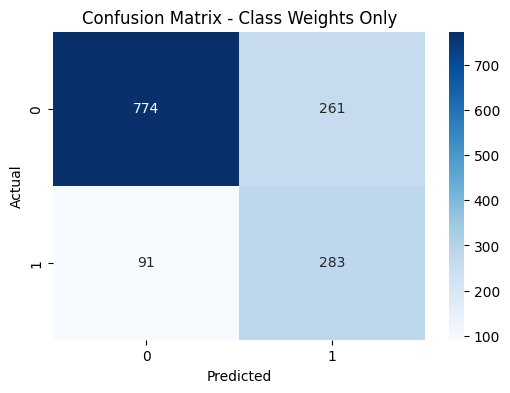

In [7]:
# Calculate class weights
# Classes
classes = np.unique(y_train)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# Convert to dictionary
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

# Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,  # applies class weights
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Class Weights Only')
plt.show()

# **2. SMOTE**

After SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6311 - auc: 0.6490 - f1_score: 0.3706 - loss: 0.6287 - precision: 0.5326 - recall: 0.3110 - val_accuracy: 0.6202 - val_auc: 0.0000e+00 - val_f1_score: 0.7627 - val_loss: 0.7310 - val_precision: 1.0000 - val_recall: 0.6202
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7666 - auc: 0.8333 - f1_score: 0.6689 - loss: 0.4842 - precision: 0.7038 - recall: 0.6476 - val_accuracy: 0.6751 - val_auc: 0.0000e+00 - val_f1_score: 0.8036 - val_loss: 0.6780 - val_precision: 1.0000 - val_recall: 0.6751
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7599 - auc: 0.8354 - f1_score: 0.6625 - loss: 0.4800 - precision: 0.6833 - recall: 0.6671 - val_accuracy: 0.6697 - val_auc: 0.0000e+00 - val_f1_score: 0.7998 - val_loss: 0.6942 - val_precision: 1.0000 - val_recall: 0.6697
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7691 - auc: 0.8390 - f1_score: 0.6795 - loss: 0.4763 - precision: 0.6949 - recall

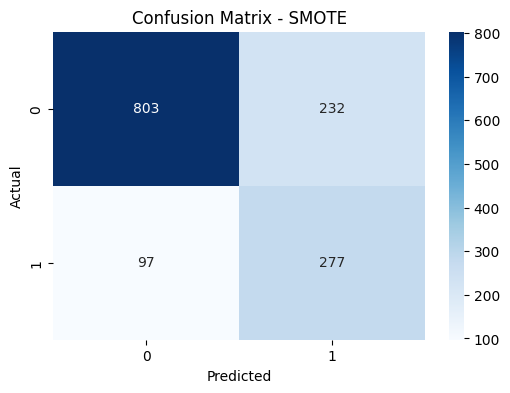

In [8]:
# Initialize SMOTE
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE class counts:\n", pd.Series(y_train_smote).value_counts())

# Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train Model
history = model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SMOTE')
plt.show()

# **3. Borderline SMOTE - 1**

After Borderline-SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6292 - auc: 0.7304 - f1_score: 0.0994 - loss: 0.6053 - precision: 0.4746 - recall: 0.0674 - val_accuracy: 0.4764 - val_auc: 0.0000e+00 - val_f1_score: 0.6394 - val_loss: 0.8365 - val_precision: 1.0000 - val_recall: 0.4764
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7445 - auc: 0.8125 - f1_score: 0.6460 - loss: 0.5142 - precision: 0.6696 - recall: 0.6423 - val_accuracy: 0.6347 - val_auc: 0.0000e+00 - val_f1_score: 0.7730 - val_loss: 0.7646 - val_precision: 1.0000 - val_recall: 0.6347
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7428 - auc: 0.8127 - f1_score: 0.6583 - loss: 0.5045 - precision: 0.6487 - recall: 0.6884 - val_accuracy: 0.6957 - val_auc: 0.0000e+00 - val_f1_score: 0.8177 - val_loss: 0.6569 - val_precision: 1.0000 - val_recall: 0.6957
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7442 - auc: 0.8179 - f1_score: 0.6642 - loss: 0.4994 - precision: 0.6419 - recall

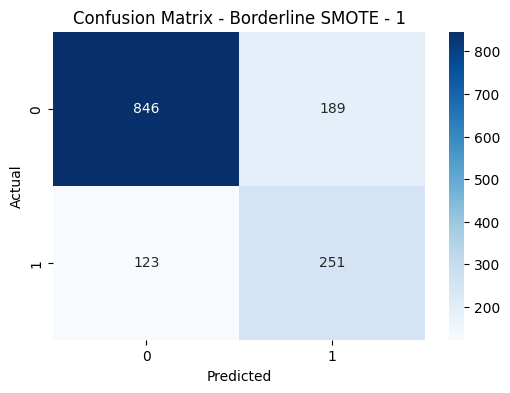

In [9]:
# Initialize Borderline-SMOTE
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-1'
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_smote).value_counts())

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train Model
history = model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Borderline SMOTE - 1')
plt.show()

# **4. Borderline SMOTE - 2**

After Borderline-SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6200 - auc: 0.6266 - f1_score: 0.1770 - loss: 0.6275 - precision: 0.4809 - recall: 0.1283 - val_accuracy: 0.5296 - val_auc: 0.0000e+00 - val_f1_score: 0.6866 - val_loss: 0.8049 - val_precision: 1.0000 - val_recall: 0.5296
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7397 - auc: 0.8126 - f1_score: 0.6503 - loss: 0.5094 - precision: 0.6574 - recall: 0.6610 - val_accuracy: 0.6045 - val_auc: 0.0000e+00 - val_f1_score: 0.7499 - val_loss: 0.7555 - val_precision: 1.0000 - val_recall: 0.6045
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7465 - auc: 0.8186 - f1_score: 0.6609 - loss: 0.4966 - precision: 0.6565 - recall: 0.6808 - val_accuracy: 0.6274 - val_auc: 0.0000e+00 - val_f1_score: 0.7679 - val_loss: 0.7408 - val_precision: 1.0000 - val_recall: 0.6274
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7528 - auc: 0.8217 - f1_score: 0.6731 - loss: 0.4922 - precision: 0.6573 - recall

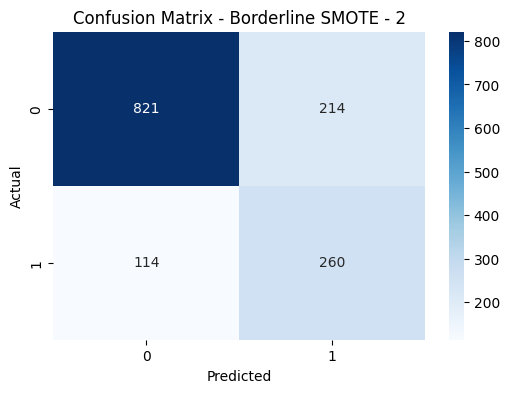

In [10]:
# Initialize Borderline-SMOTE
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-2'
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_smote).value_counts())

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train Model
history = model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Borderline SMOTE - 2')
plt.show()

# **5. ADASYN**

After ADASYN class counts:
 Churn
1    4152
0    4139
Name: count, dtype: int64
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6278 - auc: 0.6682 - f1_score: 0.0865 - loss: 0.6128 - precision: 0.4361 - recall: 0.0621 - val_accuracy: 0.5105 - val_auc: 0.0000e+00 - val_f1_score: 0.6653 - val_loss: 0.8791 - val_precision: 1.0000 - val_recall: 0.5105
Epoch 2/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7268 - auc: 0.7815 - f1_score: 0.5966 - loss: 0.5357 - precision: 0.6384 - recall: 0.5842 - val_accuracy: 0.5931 - val_auc: 0.0000e+00 - val_f1_score: 0.7371 - val_loss: 0.7951 - val_precision: 1.0000 - val_recall: 0.5931
Epoch 3/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7328 - auc: 0.7965 - f1_score: 0.6405 - loss: 0.5220 - precision: 0.6473 - recall: 0.6564 - val_accuracy: 0.5395 - val_auc: 0.0000e+00 - val_f1_score: 0.6925 - val_loss: 0.8559 - val_precision: 1.0000 - val_recall: 0.5395
Epoch 4/50
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7410 - auc: 0.8074 - f1_score: 0.6422 - loss: 0.5073 - precision: 0.6508 - recall

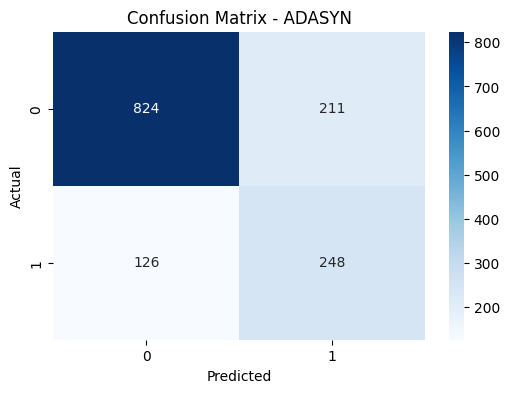

In [ ]:
#Apply ADASYN
adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=42,
    n_neighbors=5
)

X_train_aug, y_train_aug = adasyn.fit_resample(X_train, y_train)

print("After ADASYN class counts:\n", pd.Series(y_train_aug).value_counts())

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train the model
history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ADASYN')
plt.show()

# **6. Class Weights + SMOTE**

After SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5516 - auc: 0.5587 - f1_score: 0.1998 - loss: 0.6593 - precision: 0.3610 - recall: 0.2079 - val_accuracy: 0.5151 - val_auc: 0.0000e+00 - val_f1_score: 0.6765 - val_loss: 0.8349 - val_precision: 1.0000 - val_recall: 0.5151
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7449 - auc: 0.8202 - f1_score: 0.6017 - loss: 0.4997 - precision: 0.6953 - recall: 0.5583 - val_accuracy: 0.6691 - val_auc: 0.0000e+00 - val_f1_score: 0.7995 - val_loss: 0.7004 - val_precision: 1.0000 - val_recall: 0.6691
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7635 - auc: 0.8307 - f1_score: 0.6722 - loss: 0.4857 - precision: 0.6859 - recall: 0.6734 - val_accuracy: 0.7234 - val_auc: 0.0000e+00 - val_f1_score: 0.8374 - val_loss: 0.6246 - val_precision: 1.0000 - val_recall: 0.7234
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7626 - auc: 0.8300 - f1_score: 0.6826 - loss: 0.4876 - precision: 0.6816 - recall

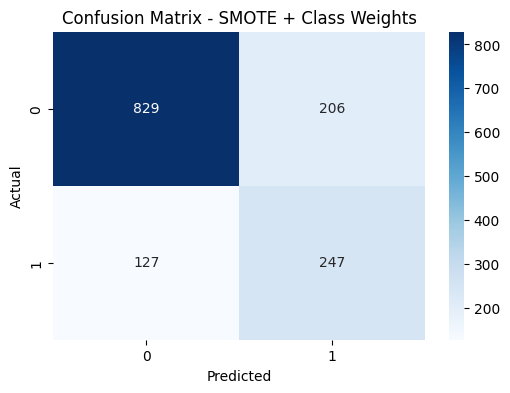

In [ ]:
# 1. Apply SMOTE
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

print("After SMOTE class counts:\n", pd.Series(y_train_aug).value_counts())

# Compute class weights
classes = np.unique(y_train_aug)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_aug)
class_weight_dict = dict(zip(classes, class_weights_values))
print("Class weights:", class_weight_dict)

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train the model
history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SMOTE + Class Weights')
plt.show()

# **7. Class Weights + Borderline SMOTE - 1**

After Borderline-SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5599 - auc: 0.5924 - f1_score: 0.2628 - loss: 0.6742 - precision: 0.3957 - recall: 0.2916 - val_accuracy: 0.3382 - val_auc: 0.0000e+00 - val_f1_score: 0.5015 - val_loss: 0.8754 - val_precision: 1.0000 - val_recall: 0.3382
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7311 - auc: 0.8119 - f1_score: 0.5767 - loss: 0.5208 - precision: 0.6874 - recall: 0.5182 - val_accuracy: 0.6093 - val_auc: 0.0000e+00 - val_f1_score: 0.7525 - val_loss: 0.7346 - val_precision: 1.0000 - val_recall: 0.6093
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7413 - auc: 0.8178 - f1_score: 0.6483 - loss: 0.4981 - precision: 0.6521 - recall: 0.6591 - val_accuracy: 0.6141 - val_auc: 0.0000e+00 - val_f1_score: 0.7570 - val_loss: 0.7360 - val_precision: 1.0000 - val_recall: 0.6141
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7510 - auc: 0.8258 - f1_score: 0.6605 - loss: 0.4872 - precision: 0.6618 - recall

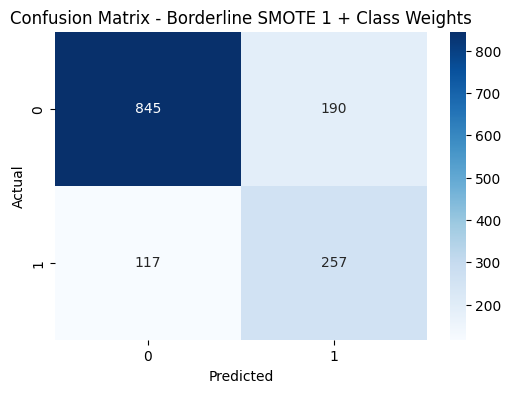

In [11]:
# Apply Borderline-SMOTE
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-1'
)

X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_aug).value_counts())

# Compute class weights
classes = np.unique(y_train_aug)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_aug)
class_weight_dict = dict(zip(classes, class_weights_values))
print("Class weights:", class_weight_dict)

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train the model
history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Borderline SMOTE 1 + Class Weights')
plt.show()

# **8. Class Weights + Borderline SMOTE - 2**

After Borderline-SMOTE class counts:
 Churn
0    4139
1    4139
Name: count, dtype: int64
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6860 - auc: 0.7607 - f1_score: 0.3889 - loss: 0.5976 - precision: 0.6904 - recall: 0.3047 - val_accuracy: 0.5380 - val_auc: 0.0000e+00 - val_f1_score: 0.6947 - val_loss: 0.8244 - val_precision: 1.0000 - val_recall: 0.5380
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7393 - auc: 0.8029 - f1_score: 0.6556 - loss: 0.5208 - precision: 0.6630 - recall: 0.6660 - val_accuracy: 0.6039 - val_auc: 0.0000e+00 - val_f1_score: 0.7496 - val_loss: 0.7577 - val_precision: 1.0000 - val_recall: 0.6039
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7510 - auc: 0.8173 - f1_score: 0.6615 - loss: 0.4952 - precision: 0.6550 - recall: 0.6846 - val_accuracy: 0.6510 - val_auc: 0.0000e+00 - val_f1_score: 0.7856 - val_loss: 0.6795 - val_precision: 1.0000 - val_recall: 0.6510
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7485 - auc: 0.8245 - f1_score: 0.6703 - loss: 0.4895 - precision: 0.6561 - recal

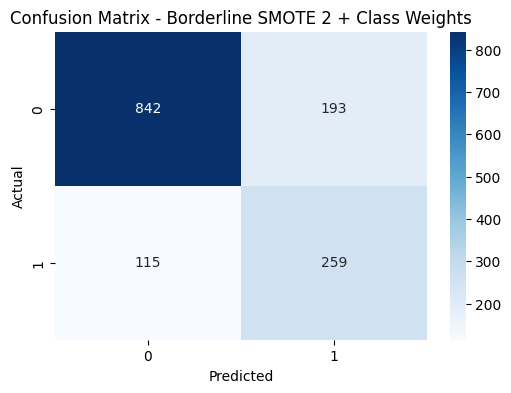

In [12]:
# Apply Borderline-SMOTE
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-2'
)

X_train_aug, y_train_aug = smote.fit_resample(X_train, y_train)

print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_aug).value_counts())

# Compute class weights
classes = np.unique(y_train_aug)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_aug)
class_weight_dict = dict(zip(classes, class_weights_values))
print("Class weights:", class_weight_dict)

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train the model
history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Borderline SMOTE 2 + Class Weights')
plt.show()

# **9. Class Weights + ADASYN**

After ADASYN class counts:
 Churn
0    4139
1    4030
Name: count, dtype: int64
Class weights: {np.int64(0): np.float64(0.9868325682532012), np.int64(1): np.float64(1.0135235732009926)}
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6487 - auc: 0.7338 - f1_score: 0.0504 - loss: 0.6007 - precision: 0.6209 - recall: 0.0356 - val_accuracy: 0.3421 - val_auc: 0.0000e+00 - val_f1_score: 0.4877 - val_loss: 1.0059 - val_precision: 1.0000 - val_recall: 0.3421
Epoch 2/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7227 - auc: 0.7848 - f1_score: 0.5543 - loss: 0.5482 - precision: 0.6708 - recall: 0.4957 - val_accuracy: 0.5135 - val_auc: 0.0000e+00 - val_f1_score: 0.6550 - val_loss: 0.9539 - val_precision: 1.0000 - val_recall: 0.5135
Epoch 3/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7358 - auc: 0.8034 - f1_score: 0.6069 - loss: 0.5189 - precision: 0.6395 - recall: 0.6059 - val_accuracy: 0.5802 - val_auc: 0.0000e+00 - val_f1_score: 0.7303 - val_loss: 0.8773 - val_precision: 1.0000 - val_recall: 0.5802
Epoch 4/50
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7367 - auc: 0.8004 - f1_score: 0.6517 - loss: 0.5247 - precision: 0.6532 - recall

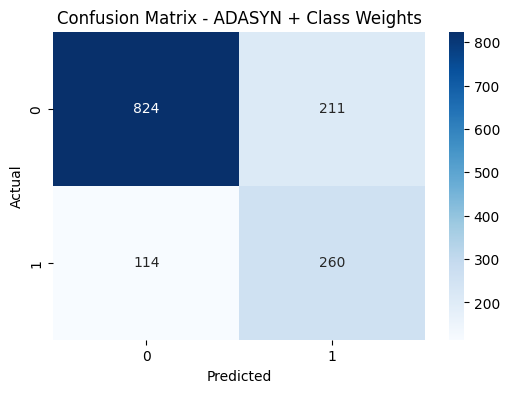

In [13]:
# Apply ADASYN
adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=42,
    n_neighbors=5
)

X_train_aug, y_train_aug = adasyn.fit_resample(X_train, y_train)

print("After ADASYN class counts:\n", pd.Series(y_train_aug).value_counts())

# Compute class weights
classes = np.unique(y_train_aug)
class_weights_values = compute_class_weight(class_weight='balanced',
                                            classes=classes,
                                            y=y_train_aug)
class_weight_dict = dict(zip(classes, class_weights_values))
print("Class weights:", class_weight_dict)

#Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(
    units=16,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second hidden layer
model.add(Dense(
    units=8,
    activation='relu'
))

# Output layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Define the custom F1 score metric
def f1_score(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall'),
        AUC(name='auc'),
        f1_score
    ]
)

# Train the model
history = model.fit(
    X_train_aug,
    y_train_aug,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on test set
results = model.evaluate(X_test, y_test)

# Print overall test metrics
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# Print classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, digits=4))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(cm)

# Visualize it as a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - ADASYN + Class Weights')
plt.show()

# **SUMMARY**
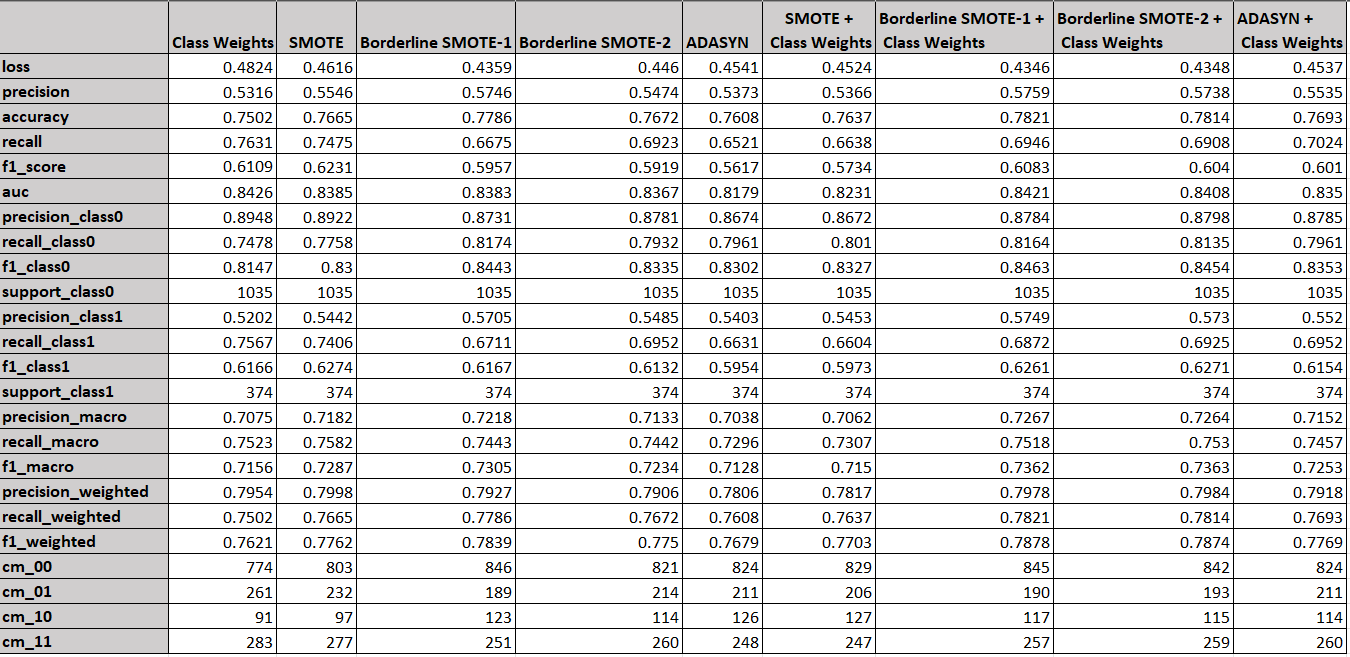